# Compare the different optimisations

## Set up

In [1]:
# Imports
import pandas as pd
import xarray as xr 
import numpy as np
from seapopym.standard import coordinates
import matplotlib.pyplot as plt

In [2]:
# Load csv
df_ar_1=pd.read_csv("gam_aragonite_1_best_pred.csv",index_col=0,parse_dates=True).squeeze()
df_ar_2=pd.read_csv("gam_aragonite_2_best_pred.csv",index_col=0,parse_dates=True).squeeze()
df_opti_6=pd.read_csv("gam_opti_6_best_pred.csv",index_col=0,parse_dates=True).squeeze()
df_opti_6_bis=pd.read_csv("no_ph_gam_opti_6_bis_best_pred.csv",index_col=0,parse_dates=True).squeeze()
df_ar_1=np.log10(df_ar_1).reset_index()
df_ar_1.columns=["time","biomass"]
df_ar_2=np.log10(df_ar_2).reset_index()
df_ar_2.columns=["time","biomass"]
df_opti_6=np.log10(df_opti_6).reset_index()
df_opti_6.columns=["time","biomass"]
df_opti_6_bis=np.log10(df_opti_6_bis).reset_index()
df_opti_6_bis.columns=["time","biomass"]

[]

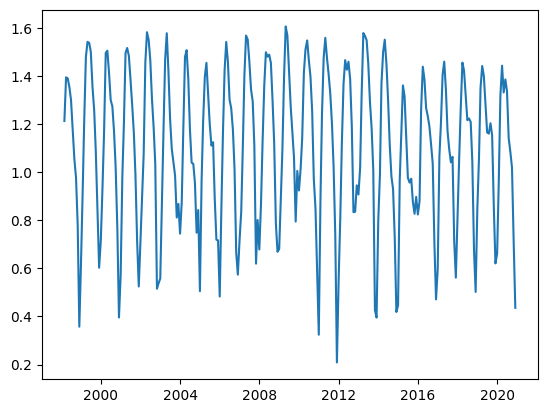

In [3]:
plt.plot(df_ar_1["time"],df_ar_1["biomass"])
plt.plot()

In [4]:
# Load obs
# WARNING : chose btw with or w/o outliers, and which k
path_obs="/data/rd_exchange/sroyer/SEAPOPYM/time_serie_pter_papa_1998_2020_clean_k_075.nc"
ds_obs = xr.open_dataset(path_obs,engine='netcdf4')
data_pter=ds_obs['pteropod_biomass_gm2']

observations = xr.DataArray(
    dims=["time", "latitude", "longitude", "layer"],
    coords={
        "time": coordinates.new_time(pd.to_datetime(data_pter.time)),
        "layer": coordinates.new_layer([0]),
        "latitude": coordinates.new_latitude([0]),
        "longitude": coordinates.new_longitude([0]),
    },
    attrs={"units": 'g m-2'},
    data=data_pter.values[:, np.newaxis, np.newaxis, np.newaxis],
)

observations=observations.pint.quantify().pint.to("gram/meter^2").pint.dequantify()
observations = xr.Dataset({"day":observations}) 

# Remove the X first obs to let the model reach the stationary state
observations_selected_without_init = observations.isel(time=slice(12, None)) # STABILIZATION_TIME=12


observations_day_pandas = (
    observations_selected_without_init.pint.quantify()
    .pint.to("mg/meter^2")
    .pint.dequantify()
    .day.dropna("time")
    .to_dataframe()
    .reset_index()
    .set_index("time")["day"]
)

df_obs = observations_day_pandas.resample("ME").mean()[:].dropna()
df_obs.index = df_obs.index.to_period("M").to_timestamp()
df_obs=np.log10(df_obs).reset_index()
df_obs.columns=["time","biomass"]
df_obs

,time,biomass
0,1998-06-01,2.050884
1,1998-07-01,1.332392
2,1998-08-01,2.058783
3,1998-10-01,1.166646
4,1999-05-01,1.972597
...,...,...
107,2019-09-01,1.118378
108,2020-02-01,1.584741
109,2020-06-01,1.323429
110,2020-07-01,1.157356


## GAM

In [5]:
np.int = int  # Patch temporaire pour compatibilité pygam
from pygam import LinearGAM, s, l
import scipy.sparse
# Patch temporaire : ajoute un attribut `.A` à scipy.sparse matrices
scipy.sparse.csr_matrix.A = property(lambda self: self.toarray())

In [6]:
def decompose_GAM(data,variable):
    """Decompose time series using GAM model into trend and seasonality, 
    all the calculations are in the log10 base
    
    Parameters:
            data (dataframe): must contain 'time' and the target variable to decompose
            variable (str) : name of the variable in the model, 
                must be log10 transform and monthly values
    
    Returns:
        (trend_df,season_df):DataFrame with 'time' and 'biomass' columns
    
    """
    data=data.copy()

    data = data.dropna().reset_index(drop=True)
    data['time_float'] = (data['time'] - data['time'].min()).dt.total_seconds() / (3600 * 24)

    data['month'] = data['time'].dt.month
    data['month_sin'] = np.sin(2 * np.pi * (data['month'] - 1) / 12)
    data['month_cos'] = np.cos(2 * np.pi * (data['month'] - 1) / 12)

    X = data[['time_float', 'month_sin', 'month_cos']].values
    y = data[variable].values
    
    # For the estimation of the long-term trend, we use a spline term with n_splines=80.
    # This controls the flexibility of the spline fit over time.
    # - A higher n_splines allows the model to capture more rapid changes (but also more noise).
    # - A lower n_splines results in a smoother trend that captures only large-scale variations.
    gam = LinearGAM(s(0, n_splines=80) + l(1) + l(2), fit_intercept=False).fit(X, y)

    trend = gam.partial_dependence(term=0, X=X)
    season = gam.partial_dependence(term=1, X=X) + gam.partial_dependence(term=2, X=X)
    residuals = y - (trend + season)

    trend_df=pd.DataFrame({
        "time": data["time"].values,
        variable: trend
    })
    season_df=pd.DataFrame({
        "time": data["time"].values,
        variable: season
    })
    residuals_df=pd.DataFrame({
        "time": data["time"].values,
        variable: residuals
    })

    return trend_df, season_df, residuals_df

In [7]:
ar1_trend,ar1_season,ar1_resid=decompose_GAM(df_ar_1,"biomass")
ar2_trend,ar2_season,ar2_resid=decompose_GAM(df_ar_2,"biomass")
opti6_trend,opti6_season,opti6_resid=decompose_GAM(df_opti_6,"biomass")
opti6bis_trend,opti6bis_season,opti6bis_resid=decompose_GAM(df_opti_6_bis,"biomass")
obs_trend,obs_season,obs_resid=decompose_GAM(df_obs,"biomass")

## Comparison

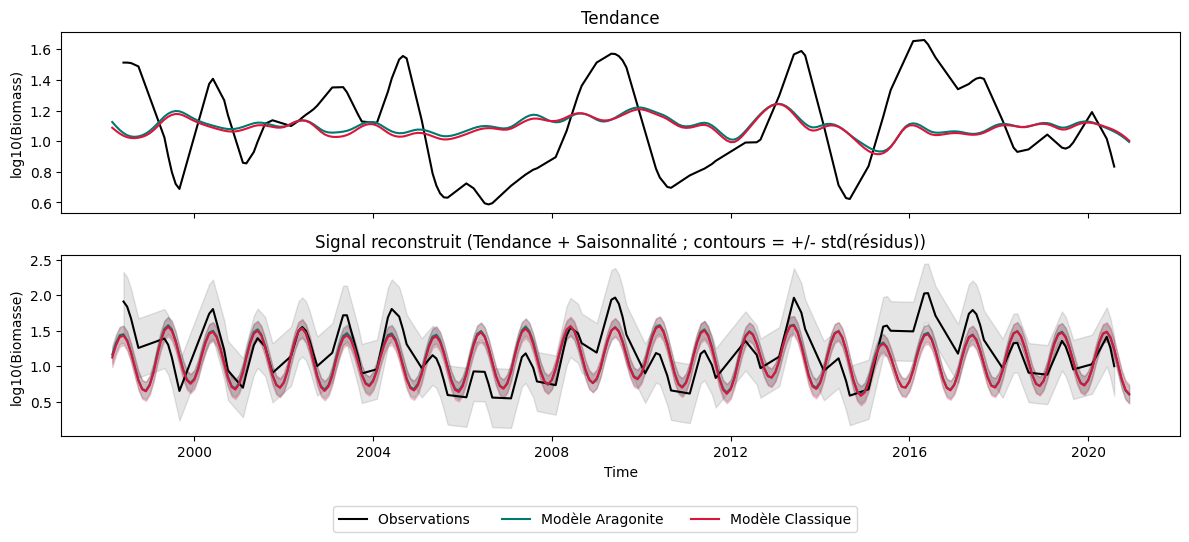

In [20]:
# plot
# Fusionner les composantes trend et season
obs_total = obs_trend.copy()
obs_total["biomass"] += obs_season["biomass"]

ar1_total = ar1_trend.copy()
ar1_total["biomass"] += ar1_season["biomass"]

opti6_total = opti6_trend.copy()
opti6_total["biomass"] += opti6_season["biomass"]

opti6bis_total = opti6bis_trend.copy()
opti6bis_total["biomass"] += opti6bis_season["biomass"]

# Création des subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

# 1. Trends
axes[0].plot(obs_trend["time"], obs_trend["biomass"], label="Observations", color='black')
axes[0].plot(ar1_trend["time"], ar1_trend["biomass"], label="Predicted Aragonite", color='#01796F')
# axes[0].plot(opti6_trend["time"], opti6_trend["biomass"], label="Predicted pH", color='orange')
axes[0].plot(opti6bis_trend["time"], opti6bis_trend["biomass"], label="Predicted classic", color='#DC143C')
axes[0].set_ylabel("log10(Biomass)")
axes[0].set_title("Tendance")


# 2. Reconstructed Signal = Trend + Seasonality (without residuals)
axes[1].plot(obs_total["time"], obs_total["biomass"], label="Observations ", color='black')
axes[1].plot(ar1_total["time"], ar1_total["biomass"], label="Modèle Aragonite", color='#01796F')
# axes[1].plot(opti6_total["time"], opti6_total["biomass"], label="Predicted pH", color='orange')
axes[1].plot(opti6bis_total["time"], opti6bis_total["biomass"], label="Modèle Classique", color='#DC143C')
# Ajout des zones d'incertitude (+/- 1 std des résidus)
obs_std = np.std(obs_resid["biomass"])
ar1_std = np.std(ar1_resid["biomass"])
opti6_std = np.std(opti6_resid["biomass"])
opti6bis_std = np.std(opti6bis_resid["biomass"])

axes[1].fill_between(obs_total["time"],
                     obs_total["biomass"] - obs_std,
                     obs_total["biomass"] + obs_std,
                     color='black', alpha=0.1)
axes[1].fill_between(ar1_total["time"],
                     ar1_total["biomass"] - ar1_std,
                     ar1_total["biomass"] + ar1_std,
                     color='#01796F', alpha=0.2)
# axes[1].fill_between(opti6_total["time"],
#                      opti6_total["biomass"] - opti6_std,
#                      opti6_total["biomass"] + opti6_std,
#                      color='orange', alpha=0.1)
axes[1].fill_between(opti6bis_total["time"],
                     opti6bis_total["biomass"] - opti6bis_std,
                     opti6bis_total["biomass"] + opti6bis_std,
                     color='#DC143C', alpha=0.2)

axes[1].set_ylabel("log10(Biomasse)")
axes[1].set_title("Signal reconstruit (Tendance + Saisonnalité ; contours = +/- std(résidus))")


lines_1, labels_1 = axes[1].get_legend_handles_labels()

fig.legend(lines_1,labels_1,loc='upper center', bbox_to_anchor=(0.5, -0.01), ncol=3)
plt.xlabel("Time")
plt.tight_layout()
plt.show()

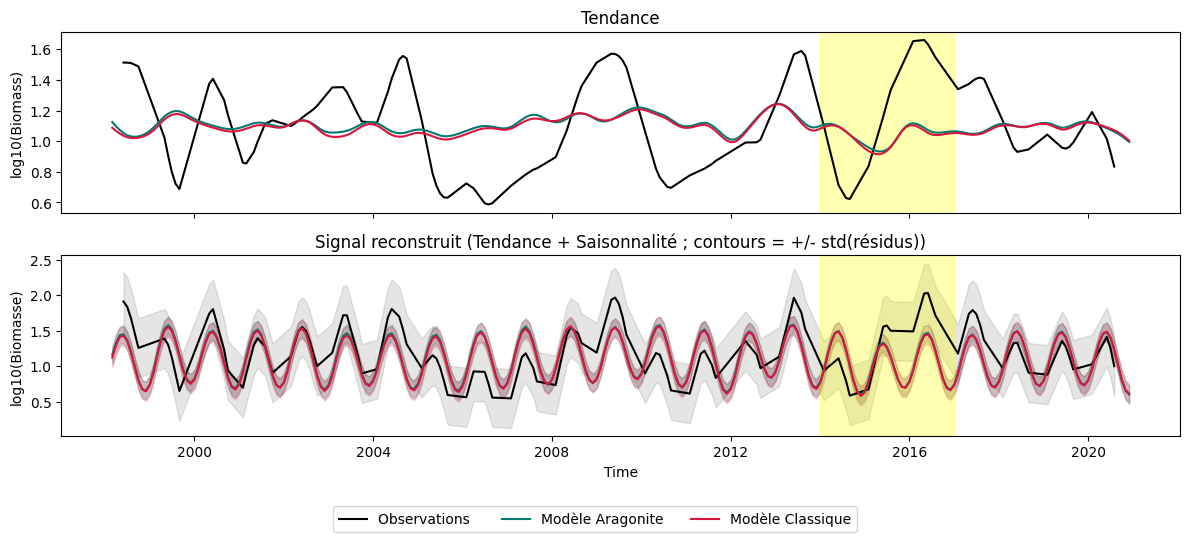

In [22]:
# plot
# Fusionner les composantes trend et season
obs_total = obs_trend.copy()
obs_total["biomass"] += obs_season["biomass"]

ar1_total = ar1_trend.copy()
ar1_total["biomass"] += ar1_season["biomass"]

opti6_total = opti6_trend.copy()
opti6_total["biomass"] += opti6_season["biomass"]

opti6bis_total = opti6bis_trend.copy()
opti6bis_total["biomass"] += opti6bis_season["biomass"]

# Création des subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

# Définir période à surligner
highlight_start = "2014-01-01"
highlight_end   = "2016-12-31"

# 1. Trends
axes[0].plot(obs_trend["time"], obs_trend["biomass"], label="Observations", color='black')
axes[0].plot(ar1_trend["time"], ar1_trend["biomass"], label="Predicted Aragonite", color='#01796F')
# axes[0].plot(opti6_trend["time"], opti6_trend["biomass"], label="Predicted pH", color='orange')
axes[0].plot(opti6bis_trend["time"], opti6bis_trend["biomass"], label="Predicted classic", color='#DC143C')
axes[0].set_ylabel("log10(Biomass)")
axes[0].set_title("Tendance")
axes[0].axvspan(highlight_start, highlight_end, color="yellow", alpha=0.3)

# 2. Reconstructed Signal = Trend + Seasonality (without residuals)
axes[1].plot(obs_total["time"], obs_total["biomass"], label="Observations ", color='black')
axes[1].plot(ar1_total["time"], ar1_total["biomass"], label="Modèle Aragonite", color='#01796F')
# axes[1].plot(opti6_total["time"], opti6_total["biomass"], label="Predicted pH", color='orange')
axes[1].plot(opti6bis_total["time"], opti6bis_total["biomass"], label="Modèle Classique", color='#DC143C')

# Ajout des zones d'incertitude (+/- 1 std des résidus)
obs_std = np.std(obs_resid["biomass"])
ar1_std = np.std(ar1_resid["biomass"])
opti6_std = np.std(opti6_resid["biomass"])
opti6bis_std = np.std(opti6bis_resid["biomass"])

axes[1].fill_between(obs_total["time"],
                     obs_total["biomass"] - obs_std,
                     obs_total["biomass"] + obs_std,
                     color='black', alpha=0.1)
axes[1].fill_between(ar1_total["time"],
                     ar1_total["biomass"] - ar1_std,
                     ar1_total["biomass"] + ar1_std,
                     color='#01796F', alpha=0.2)
# axes[1].fill_between(opti6_total["time"],
#                      opti6_total["biomass"] - opti6_std,
#                      opti6_total["biomass"] + opti6_std,
#                      color='orange', alpha=0.1)
axes[1].fill_between(opti6bis_total["time"],
                     opti6bis_total["biomass"] - opti6bis_std,
                     opti6bis_total["biomass"] + opti6bis_std,
                     color='#DC143C', alpha=0.2)

axes[1].set_ylabel("log10(Biomasse)")
axes[1].set_title("Signal reconstruit (Tendance + Saisonnalité ; contours = +/- std(résidus))")
axes[1].axvspan(highlight_start, highlight_end, color="yellow", alpha=0.3)

# Légende commune
lines_1, labels_1 = axes[1].get_legend_handles_labels()
fig.legend(lines_1, labels_1, loc='upper center', bbox_to_anchor=(0.5, -0.01), ncol=3)

plt.xlabel("Time")
plt.tight_layout()
plt.show()


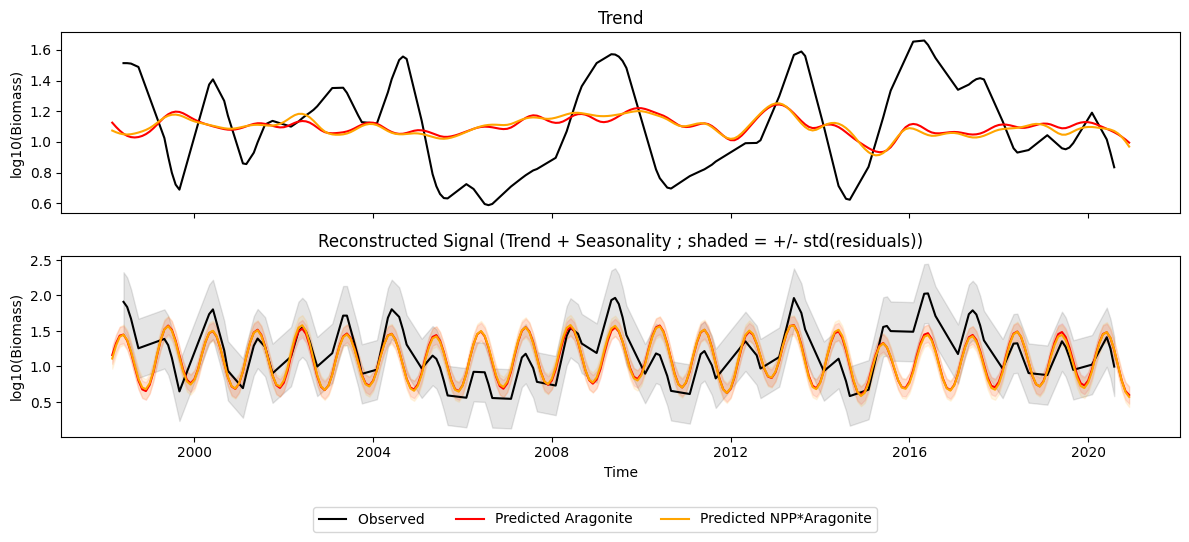

In [9]:
# plot
# Fusionner les composantes trend et season
obs_total = obs_trend.copy()
obs_total["biomass"] += obs_season["biomass"]

ar1_total = ar1_trend.copy()
ar1_total["biomass"] += ar1_season["biomass"]

ar2_total = ar2_trend.copy()
ar2_total["biomass"] += ar2_season["biomass"]

# Création des subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

# 1. Trends
axes[0].plot(obs_trend["time"], obs_trend["biomass"], label="Observed", color='black')
axes[0].plot(ar1_trend["time"], ar1_trend["biomass"], label="Predicted Aragonite", color='red')
axes[0].plot(ar2_trend["time"], ar2_trend["biomass"], label="Predicted NPP*Aragonite", color='orange')

axes[0].set_ylabel("log10(Biomass)")
axes[0].set_title("Trend")


# 2. Reconstructed Signal = Trend + Seasonality (without residuals)
axes[1].plot(obs_total["time"], obs_total["biomass"], label="Observed ", color='black')
axes[1].plot(ar1_total["time"], ar1_total["biomass"], label="Predicted Aragonite", color='red')
axes[1].plot(ar2_total["time"], ar2_total["biomass"], label="Predicted NPP*Aragonite", color='orange')

# Ajout des zones d'incertitude (+/- 1 std des résidus)
obs_std = np.std(obs_resid["biomass"])
ar1_std = np.std(ar1_resid["biomass"])
ar2_std = np.std(ar2_resid["biomass"])

axes[1].fill_between(obs_total["time"],
                     obs_total["biomass"] - obs_std,
                     obs_total["biomass"] + obs_std,
                     color='black', alpha=0.1)
axes[1].fill_between(ar1_total["time"],
                     ar1_total["biomass"] - ar1_std,
                     ar1_total["biomass"] + ar1_std,
                     color='red', alpha=0.1)
axes[1].fill_between(ar2_total["time"],
                     ar2_total["biomass"] - ar2_std,
                     ar2_total["biomass"] + ar2_std,
                     color='orange', alpha=0.1)

axes[1].set_ylabel("log10(Biomass)")
axes[1].set_title("Reconstructed Signal (Trend + Seasonality ; shaded = +/- std(residuals))")


lines_1, labels_1 = axes[1].get_legend_handles_labels()

fig.legend(lines_1,labels_1,loc='upper center', bbox_to_anchor=(0.5, -0.01), ncol=3)
plt.xlabel("Time")
plt.tight_layout()
plt.show()

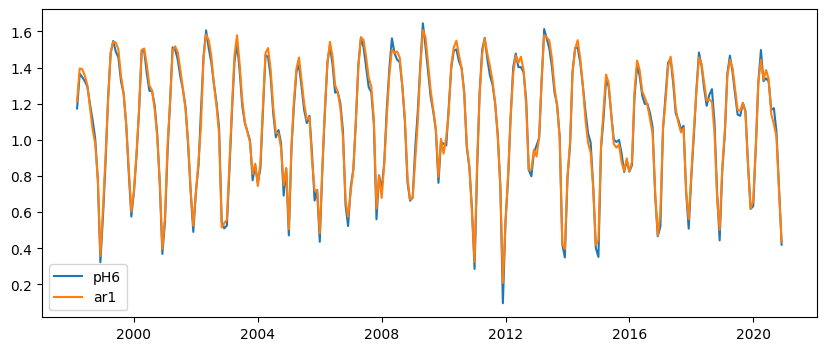

In [10]:
fig=plt.figure(figsize=(10, 4))
plt.plot(df_opti_6.time,df_opti_6.biomass,label="pH6")
plt.plot(df_ar_1['time'],df_ar_1.biomass,label="ar1")
# plt.plot(df_ar_2.time,df_ar_2.biomass,label="ar2")
plt.legend()
plt.show()

## Forçages

In [11]:
### Temperature
path_temp="/data/rd_exchange/sroyer/SEAPOPYM/3D/cmems_mod_glo_bgc_my_0.083deg-lmtl-Fphy_PT1D-i_1749126996464.nc"
ds_temp = xr.open_dataset(path_temp,engine='netcdf4')

temp = ds_temp['T'].sel(depth=1) # Extract temperature in the epipelagic layer depth
temp_papa=temp.mean(dim=['longitude','latitude'],skipna=True)

temperature = xr.DataArray(
    dims=["time"],
    coords={
        "time": coordinates.new_time(pd.to_datetime(temp.time)),

    },
    attrs={"units": "degC"},
    data=temp_papa.values[:],
)

### Aragonite (Acidity)
path_ar="/data/rd_exchange/sroyer/SEAPOPYM/monthly_aragonite_papa_1998_2020.nc"
ds_ar = xr.open_dataset(path_ar,engine='netcdf4')

# NOTE : Interpolate monthly values into daily values
target_times = pd.to_datetime(temp.time)
ar_daily = ds_ar.interp(time=target_times)
# deal with edges
ar_daily = ar_daily.ffill(dim='time')
ar_daily = ar_daily.interpolate_na(dim='time', method='linear', fill_value="extrapolate")

data_ar=ar_daily['omega_ar']

acidity = xr.DataArray(
    dims=["time"],
    coords={
        "time": coordinates.new_time(pd.to_datetime(temp.time)),
    },
    attrs={"units": "dimensionless"},
    data=data_ar.values[:],
)

### Primary productivity
# !!!!!!!!!!! be sure it's the right one !!!!!!
# #CbPM
path_pp="/data/rd_exchange/sroyer/SEAPOPYM/NPP/1998_2022_NPP_BEHRENFELD_CBPM_25KM_8D.nc"
ds_pp = xr.open_dataset(path_pp,engine='netcdf4')

pp = ds_pp['CbPM'] # Extract net primary production

# Select PAPA location and good time range 
pp_papa = pp.sel(
    lat=slice(48.5, 50.5),
    lon=slice(-130.5, -128.5),
    time=slice("1998", "2020"),
)
pp_papa=pp_papa.mean(dim=['lon','lat'],skipna=True)
pp.close()
#NOTE : Interpolate 8 day values into daily values
target_times = pd.to_datetime(temp.time)
pp_daily = pp_papa.interp(time=target_times)
# interpolate edges (+ nan values in winter : linear regression)
ds_filled = pp_daily.interpolate_na(dim='time', method='linear')
ds_filled = ds_filled.ffill(dim='time')
ds_filled = ds_filled.interpolate_na(dim='time', method='linear', fill_value="extrapolate")

primary_production = xr.DataArray(
    dims=["time"],
    coords={
        "time": coordinates.new_time(pd.to_datetime(temp.time)),
    },
    attrs={"units": "mg m-2 day-1"},
    data=ds_filled.values[:],
)

In [12]:
# Température (en °C)
df_temperature = temperature.to_dataframe(name="temperature").reset_index()

# Acidité (Ω_ar)
df_acidity = acidity.to_dataframe(name="acidity").reset_index()

# Production primaire (mg m-2 day-1)
df_primary_production = primary_production.to_dataframe(name="primary_production").reset_index()

In [13]:
temp_trend,temp_season,temp_resid=decompose_GAM(df_temperature,"temperature")
ar_trend,ar_season,ar_resid=decompose_GAM(df_acidity,"acidity")
npp_trend,npp_season,npp_resid=decompose_GAM(df_primary_production,"primary_production")


In [14]:
npp_trend

,time,primary_production
0,1998-01-01,608.833865
1,1998-01-02,612.434046
2,1998-01-03,616.016320
3,1998-01-04,619.580686
4,1998-01-05,623.127146
...,...,...
8396,2020-12-27,564.884044
8397,2020-12-28,559.015435
8398,2020-12-29,553.123319
8399,2020-12-30,547.208178


In [15]:
npp_trend_series = npp_trend.set_index("time")["primary_production"]
temp_trend_series = temp_trend.set_index("time")["temperature"]
ar_trend_series = ar_trend.set_index("time")["acidity"]
obs_trend_series = obs_trend.set_index("time")["biomass"]  


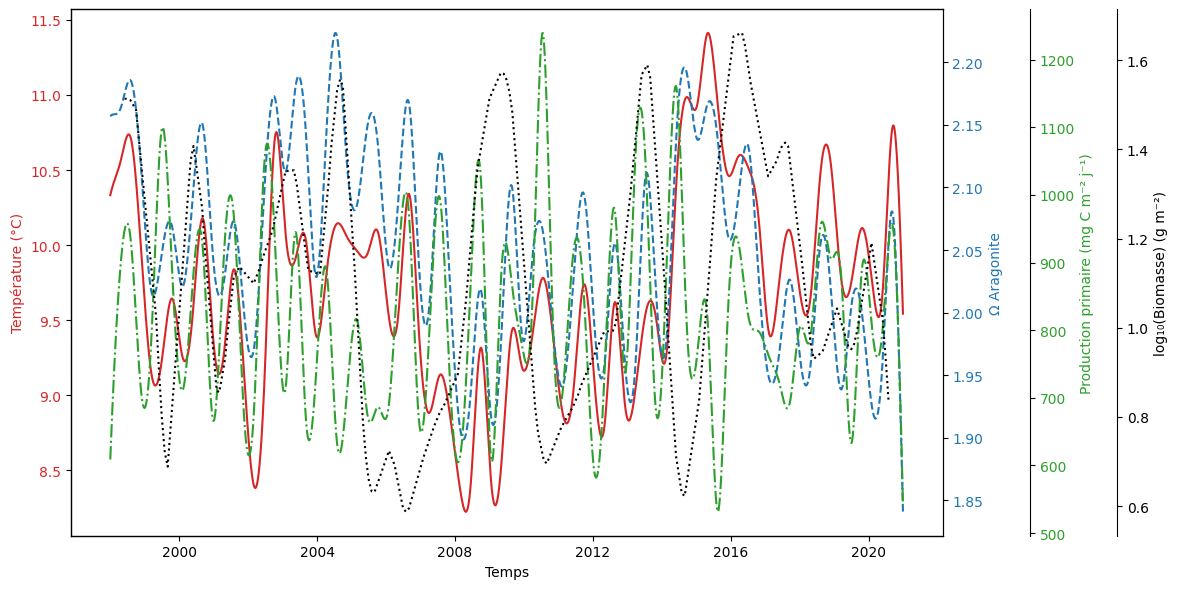

In [16]:
fig, ax1 = plt.subplots(figsize=(12, 6))

line1, = ax1.plot(temp_trend_series.index, temp_trend_series, color='tab:red', linestyle='-', label="Température (°C)")
ax1.set_ylabel("Température (°C)", color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
line2, = ax2.plot(ar_trend_series.index, ar_trend_series, color='tab:blue', linestyle='--', label="Ω Aragonite")
ax2.set_ylabel("Ω Aragonite", color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

ax3 = ax1.twinx()
ax3.spines["right"].set_position(("axes", 1.1))
line3, = ax3.plot(npp_trend_series.index, npp_trend_series, color='tab:green', linestyle='-.', label="NPP (mg C m⁻² j⁻¹)")
ax3.set_ylabel("Production primaire (mg C m⁻² j⁻¹)", color='tab:green')
ax3.tick_params(axis='y', labelcolor='tab:green')

ax4 = ax1.twinx()
ax4.spines["right"].set_position(("axes", 1.2))
line4, = ax4.plot(obs_trend_series.index, obs_trend_series, color='black', linestyle=':', label="log₁₀(Biomasse)")
ax4.set_ylabel("log₁₀(Biomasse) (g m⁻²)", color='black')
ax4.tick_params(axis='y', labelcolor='black')

ax1.set_xlabel("Temps")
lines = [line1, line2, line3, line4]
labels = [line.get_label() for line in lines]


plt.title("")
plt.tight_layout()
plt.show()


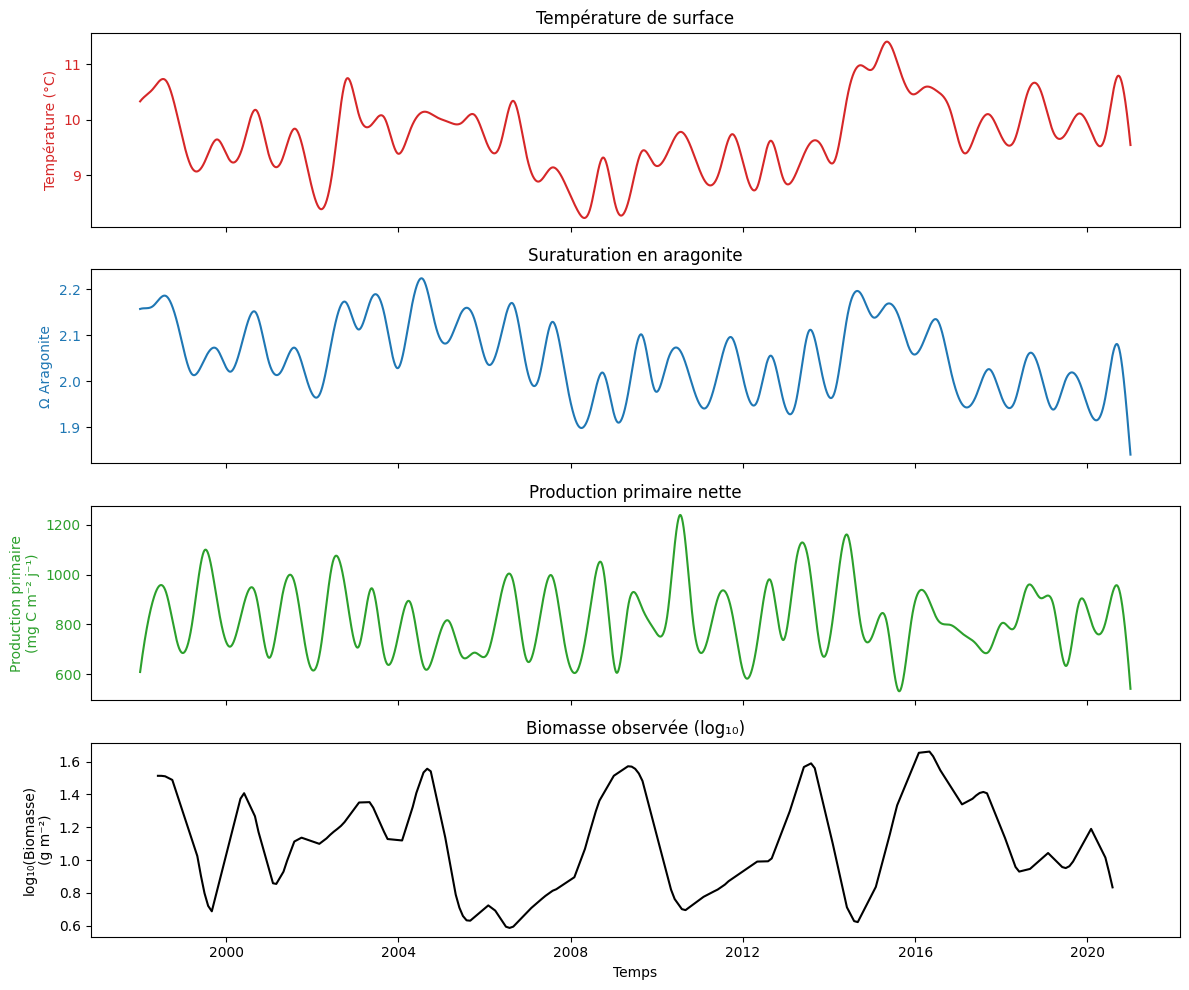

In [17]:
import matplotlib.pyplot as plt

# Crée la figure et les 4 axes
fig, axes = plt.subplots(
    nrows=4, ncols=1, figsize=(12, 10), sharex=True
)

# 1. Température
axes[0].plot(temp_trend_series.index, temp_trend_series, color='tab:red')
axes[0].set_ylabel("Température (°C)", color='tab:red')
axes[0].tick_params(axis='y', labelcolor='tab:red')
axes[0].set_title("Température de surface")

# 2. Ω Aragonite
axes[1].plot(ar_trend_series.index, ar_trend_series, color='tab:blue')
axes[1].set_ylabel("Ω Aragonite", color='tab:blue')
axes[1].tick_params(axis='y', labelcolor='tab:blue')
axes[1].set_title("Suraturation en aragonite")

# 3. Production primaire
axes[2].plot(npp_trend_series.index, npp_trend_series, color='tab:green')
axes[2].set_ylabel("Production primaire\n(mg C m⁻² j⁻¹)", color='tab:green')
axes[2].tick_params(axis='y', labelcolor='tab:green')
axes[2].set_title("Production primaire nette")

# 4. Biomasse observée
axes[3].plot(obs_trend_series.index, obs_trend_series, color='black', linestyle='-')
axes[3].set_ylabel("log₁₀(Biomasse)\n(g m⁻²)", color='black')
axes[3].tick_params(axis='y', labelcolor='black')
axes[3].set_title("Biomasse observée (log₁₀)")

# Axe des X commun
axes[3].set_xlabel("Temps")

# Ajuste l’espacement entre les subplots
plt.tight_layout()
plt.show()


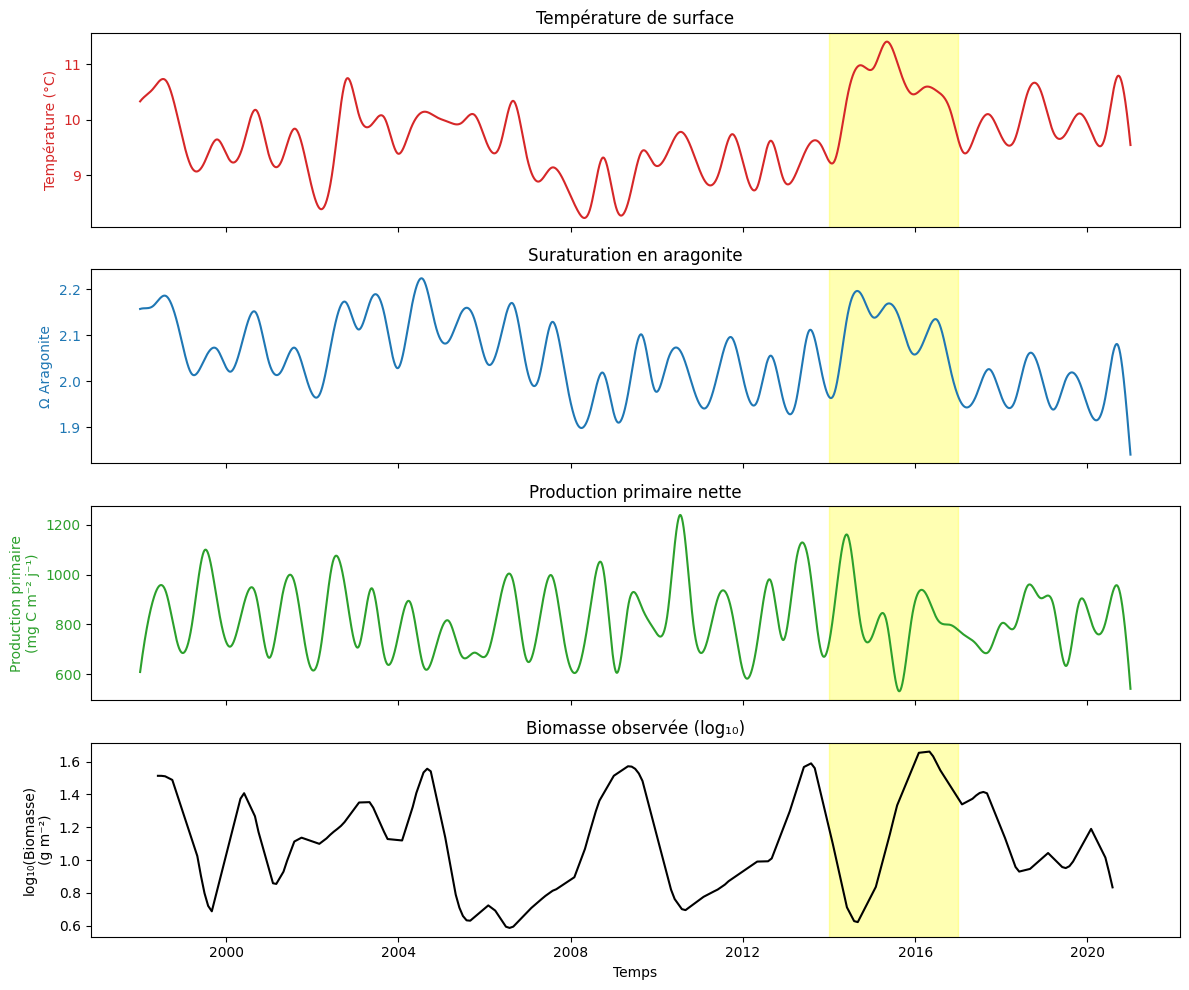

In [19]:
import matplotlib.pyplot as plt

# Crée la figure et les 4 axes
fig, axes = plt.subplots(
    nrows=4, ncols=1, figsize=(12, 10), sharex=True
)

# Période à mettre en évidence
highlight_start = "2014-01-01"
highlight_end   = "2016-12-31"

# 1. Température
axes[0].plot(temp_trend_series.index, temp_trend_series, color='tab:red')
axes[0].set_ylabel("Température (°C)", color='tab:red')
axes[0].tick_params(axis='y', labelcolor='tab:red')
axes[0].set_title("Température de surface")
axes[0].axvspan(highlight_start, highlight_end, color="yellow", alpha=0.3)

# 2. Ω Aragonite
axes[1].plot(ar_trend_series.index, ar_trend_series, color='tab:blue')
axes[1].set_ylabel("Ω Aragonite", color='tab:blue')
axes[1].tick_params(axis='y', labelcolor='tab:blue')
axes[1].set_title("Suraturation en aragonite")
axes[1].axvspan(highlight_start, highlight_end, color="yellow", alpha=0.3)

# 3. Production primaire
axes[2].plot(npp_trend_series.index, npp_trend_series, color='tab:green')
axes[2].set_ylabel("Production primaire\n(mg C m⁻² j⁻¹)", color='tab:green')
axes[2].tick_params(axis='y', labelcolor='tab:green')
axes[2].set_title("Production primaire nette")
axes[2].axvspan(highlight_start, highlight_end, color="yellow", alpha=0.3)

# 4. Biomasse observée
axes[3].plot(obs_trend_series.index, obs_trend_series, color='black', linestyle='-')
axes[3].set_ylabel("log₁₀(Biomasse)\n(g m⁻²)", color='black')
axes[3].tick_params(axis='y', labelcolor='black')
axes[3].set_title("Biomasse observée (log₁₀)")
axes[3].axvspan(highlight_start, highlight_end, color="yellow", alpha=0.3)

# Axe des X commun
axes[3].set_xlabel("Temps")

# Ajuste l’espacement entre les subplots
plt.tight_layout()
plt.show()


In [ ]:
linestyles=['-','--',':','-.','-','--',':']